- 3 zhluky -> 5 zhlukov (prekryv);

In [1]:
from sklearn.decomposition import PCA
from helper_files.feature_selection_helper import *

# PCA

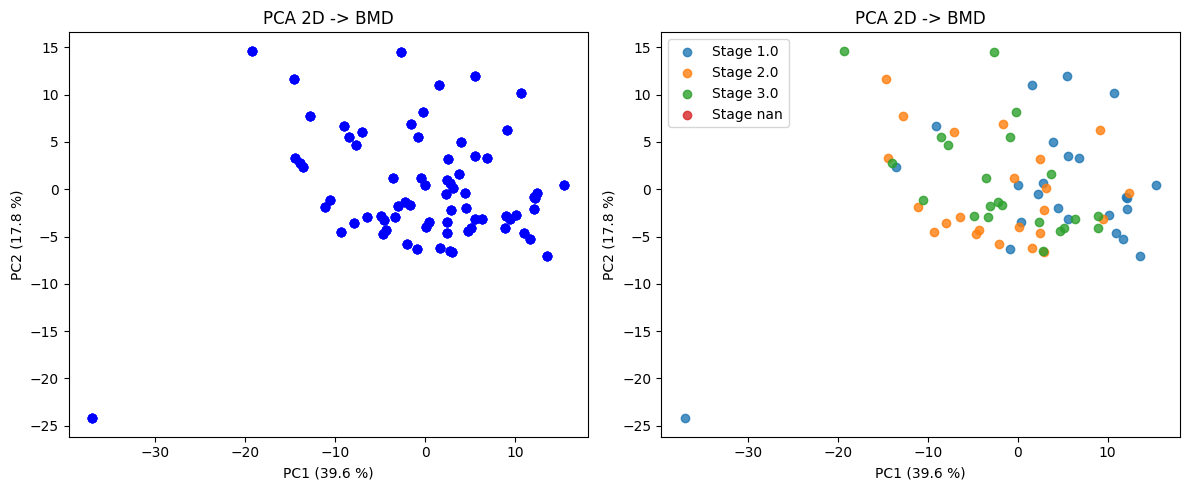

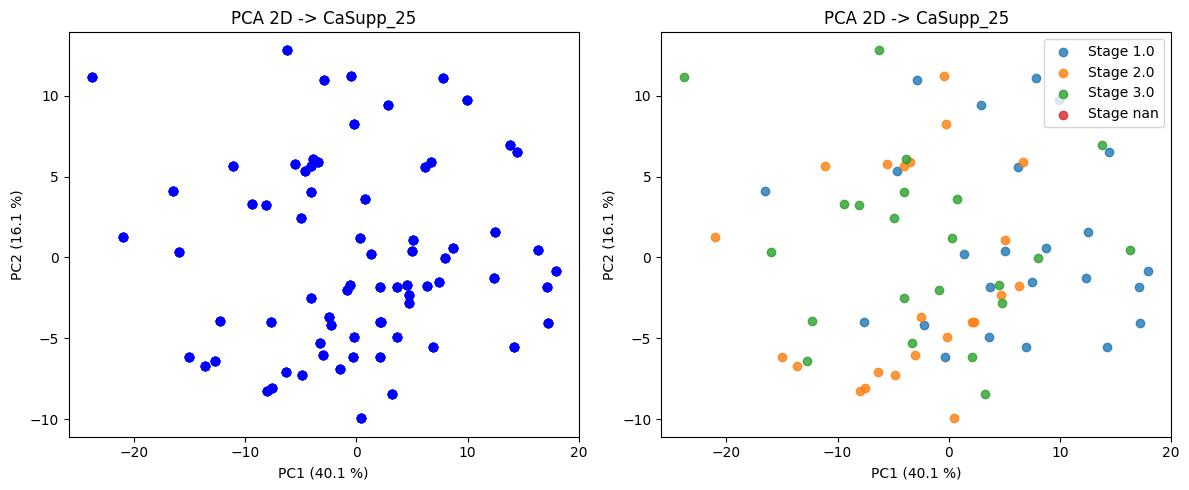

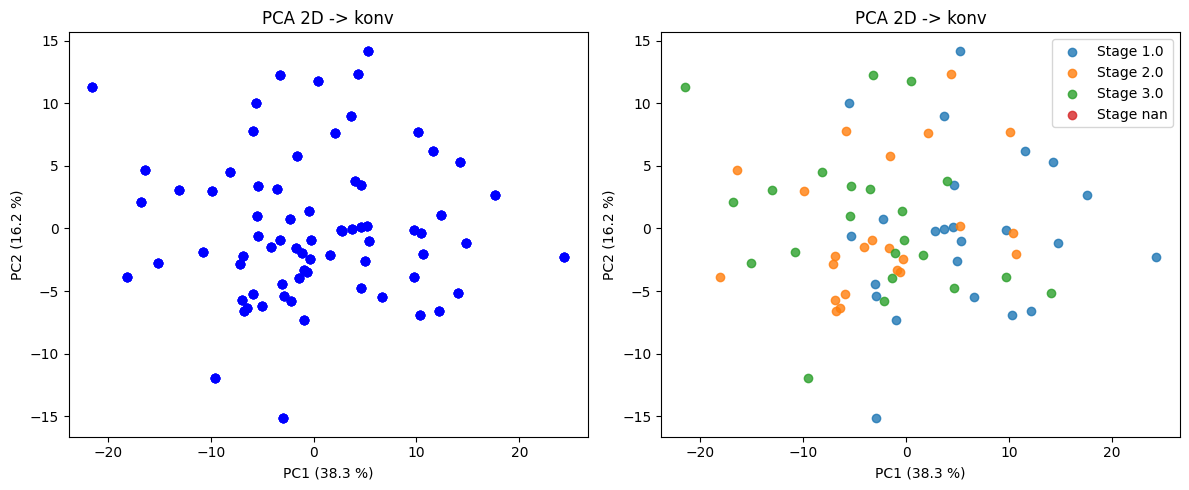

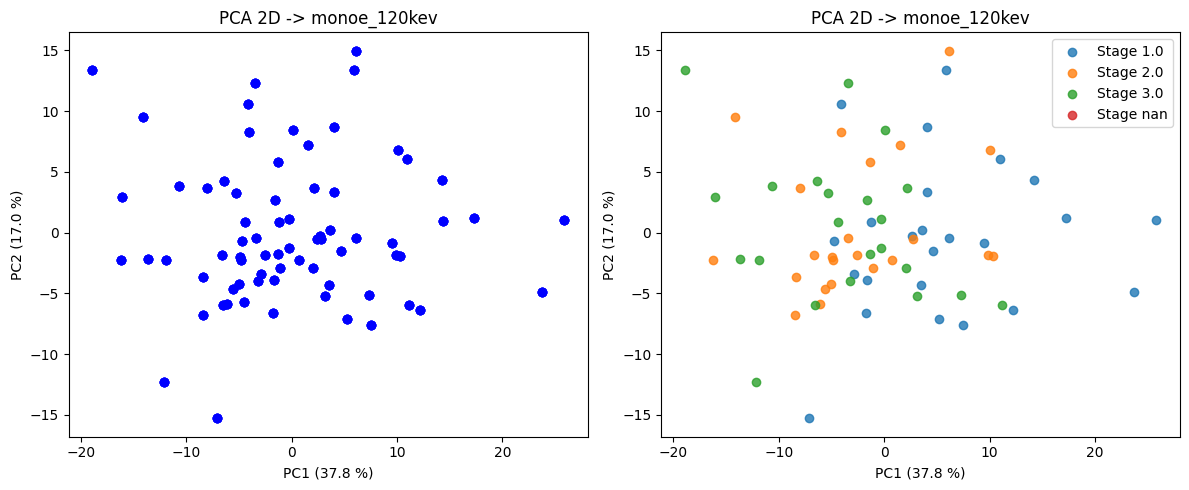

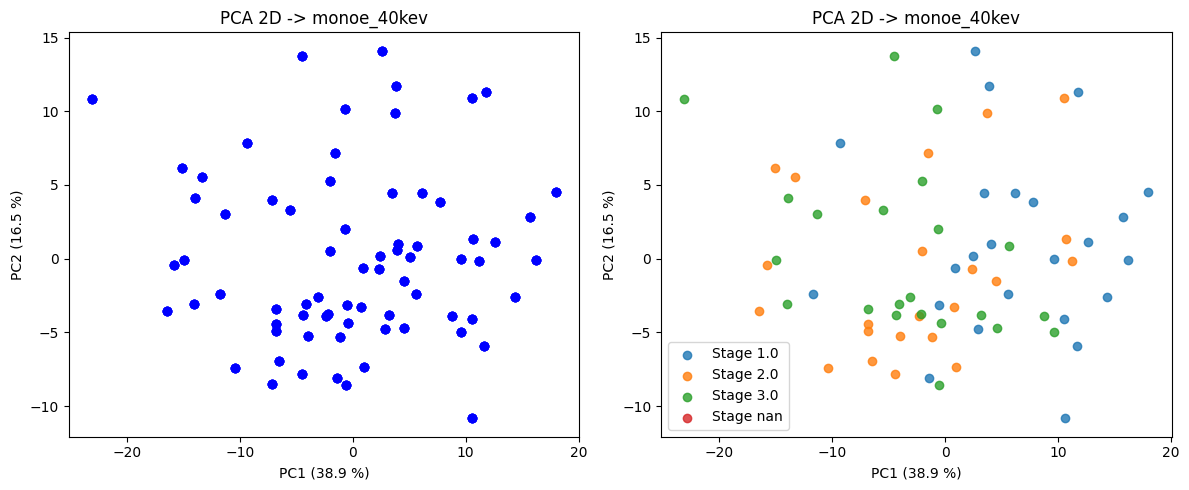

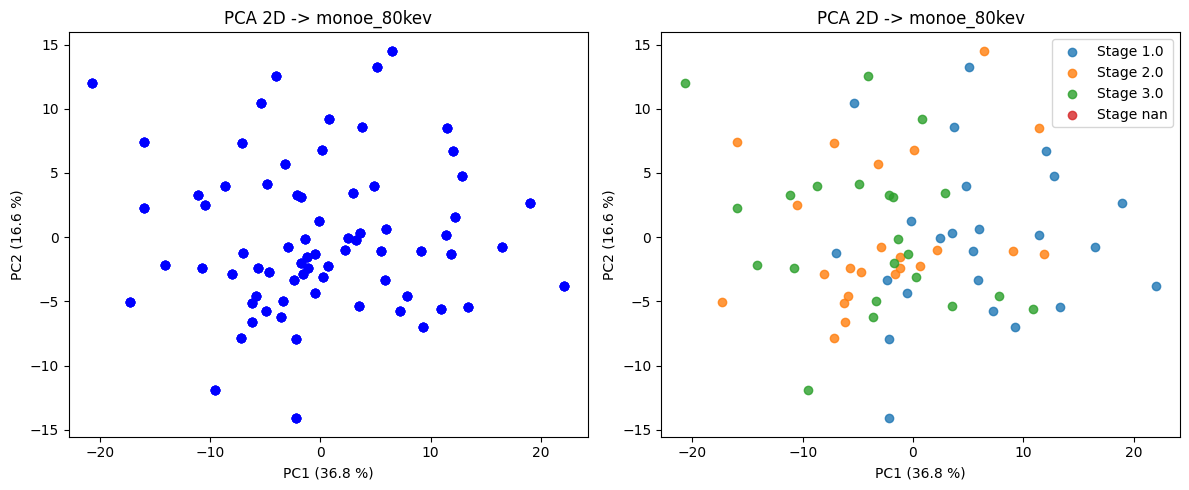

In [45]:
merged = merged_lesions_csv(r"E:\DATA_Myelomy")

clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s
        plt.subplot(122)
        plt.scatter(df_pca[idx, 0], df_pca[idx, 1], label=f"Stage {s}",alpha=0.8)
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
        plt.title(f"PCA 2D -> {df_name}")
        plt.legend()

        plt.subplot(121)
        plt.scatter(df_pca[:, 0], df_pca[:, 1], color="blue")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
        plt.title(f"PCA 2D -> {df_name}")

    plt.tight_layout()
    plt.show()

# UMAP

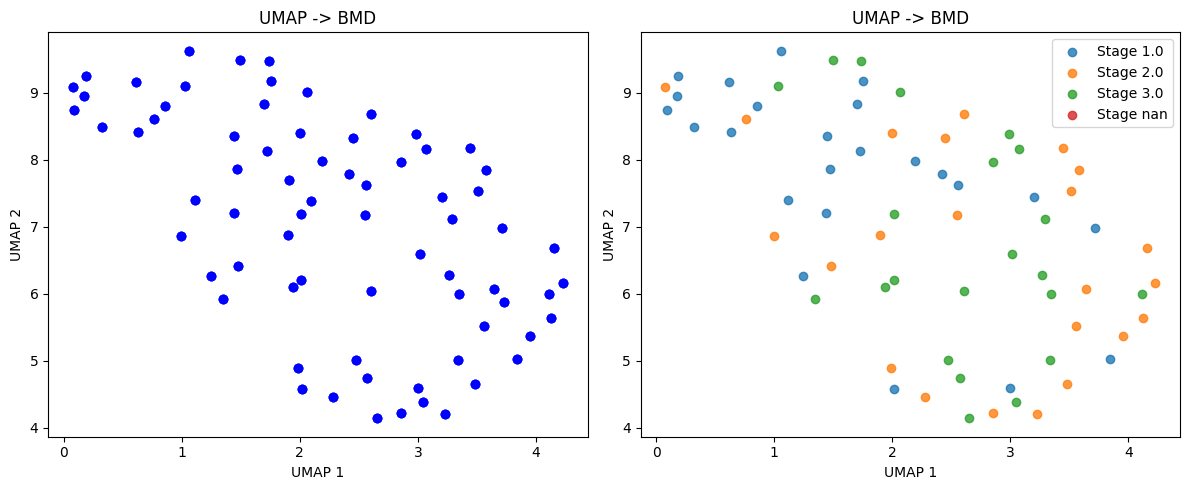

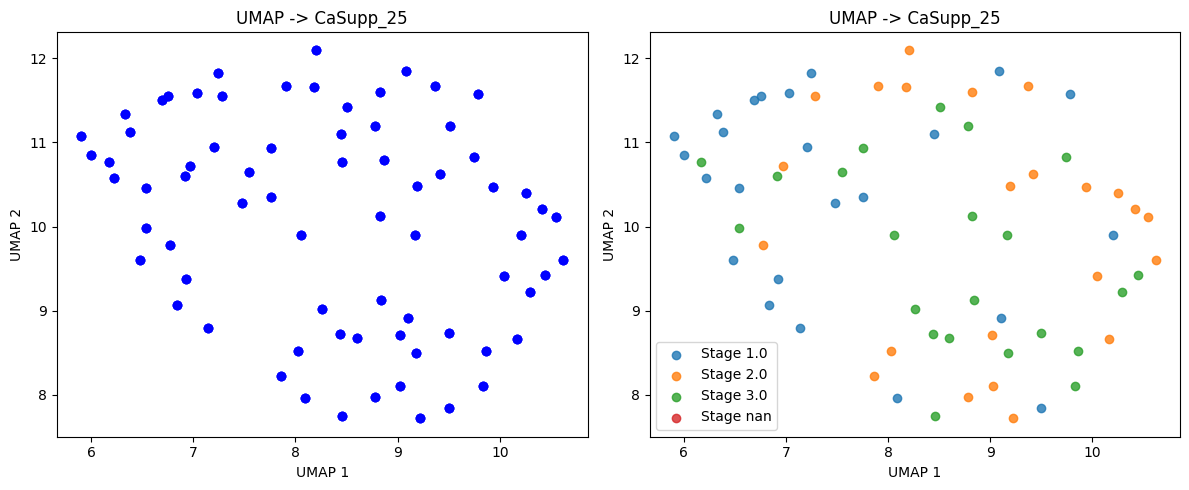

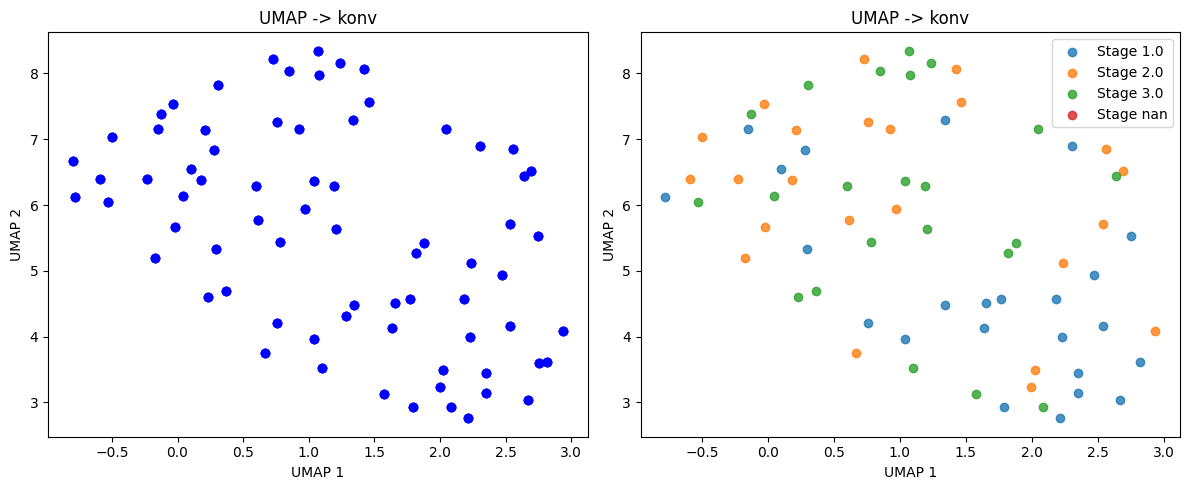

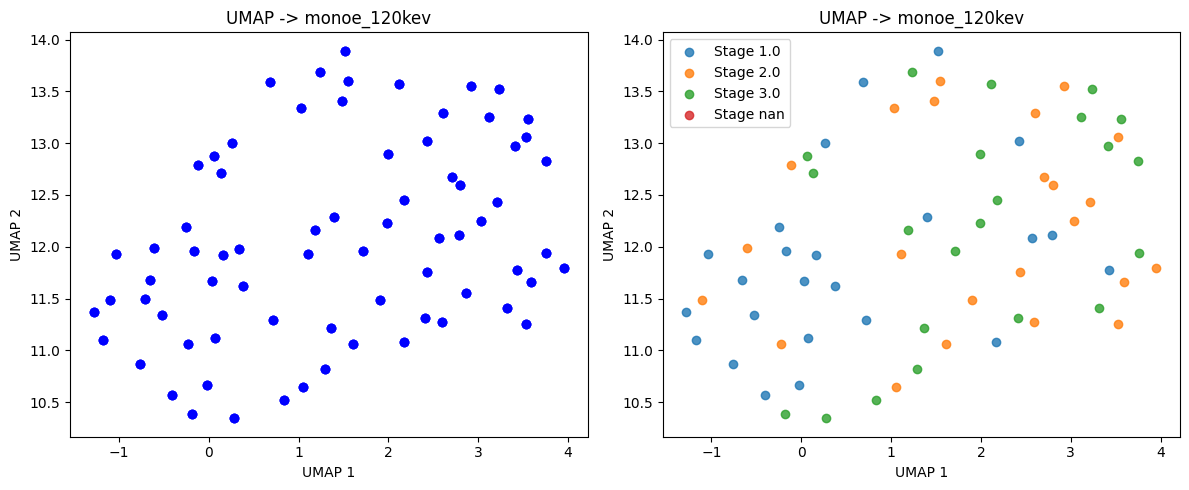

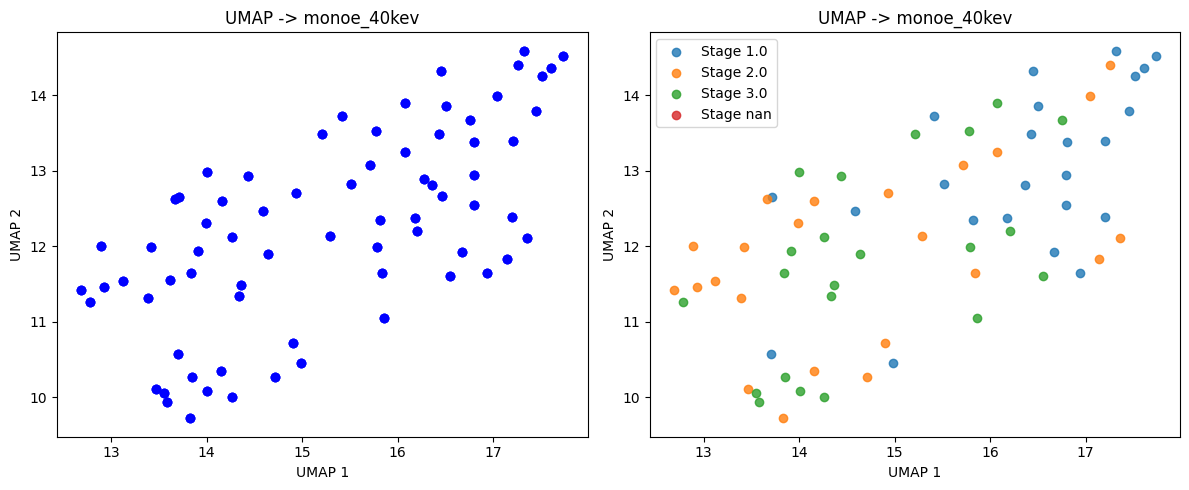

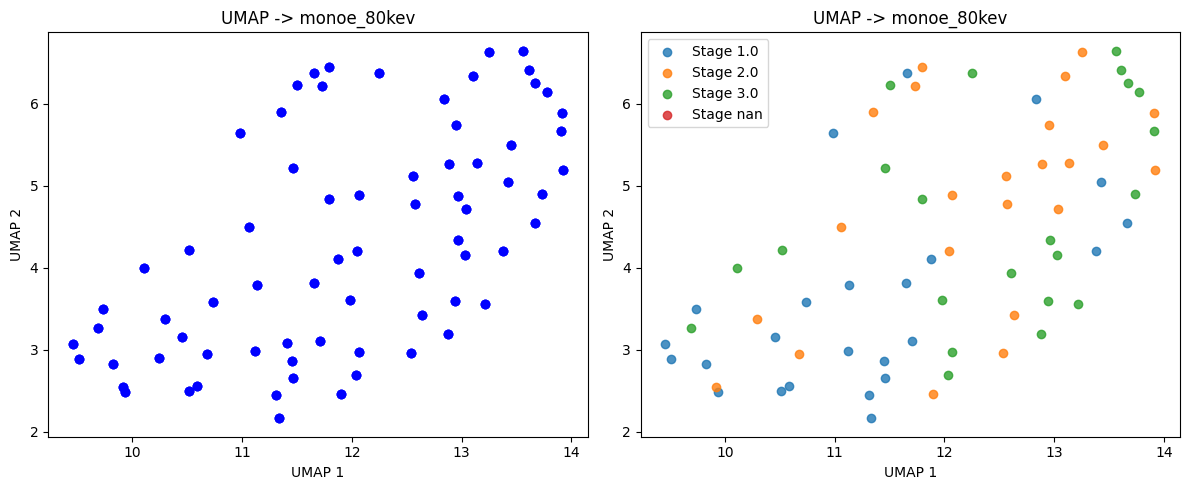

In [50]:
import umap.umap_ as umap

merged = merged_lesions_csv(r"E:\DATA_Myelomy")

clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s
        plt.subplot(122)
        plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=f"Stage {s}", alpha=0.8)
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.title(f"UMAP -> {df_name}")
        plt.legend()

        plt.subplot(121)
        plt.scatter(X_umap[:, 0], X_umap[:, 1], color='blue', alpha=0.7)
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.title(f"UMAP -> {df_name}")

    plt.tight_layout()
    plt.show()

# PCA from selected image features

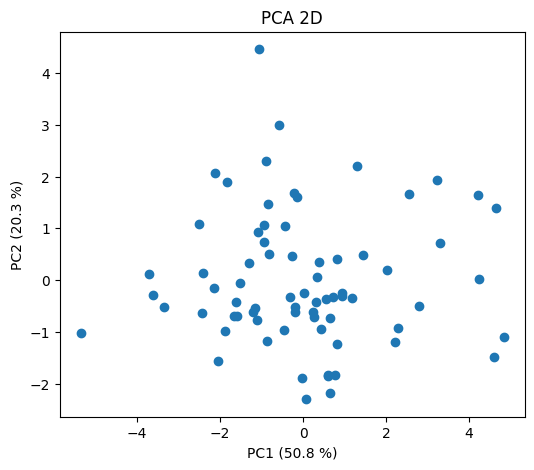

In [6]:
image_features = ["original_firstorder_Kurtosis", "original_glcm_MaximumProbability", "original_glcm_DifferenceAverage", "original_glcm_Idm",
                  "original_glcm_Id", "original_firstorder_Skewness", "gradient_glcm_Imc2", "gradient_glcm_Correlation"]

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv").filter(items=image_features)
df_scaled = StandardScaler().fit_transform(df)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(df_pca[:, 0], df_pca[:, 1])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
plt.title(f"PCA 2D")

plt.show()

# 2D clusters based on selected image features

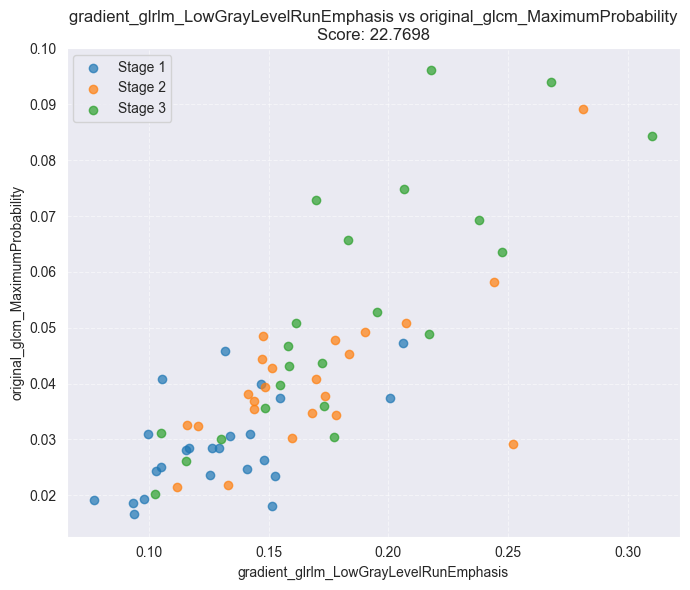

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif

img_feature1 = 'gradient_glrlm_LowGrayLevelRunEmphasis'
img_feature2 = 'original_glcm_MaximumProbability'
features = [img_feature1, img_feature2]

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

df_merged = df.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')
df_merged = df_merged[df_merged['Stage'].notna()]

X = df_merged[features].fillna(0)
y = df_merged['Stage']
f_values, _ = f_classif(X, y)
feature_f_map = dict(zip(features, f_values))


current_score = feature_f_map[img_feature1] + feature_f_map[img_feature2]
df_merged.drop(columns=['patient', 'Patient ID'], inplace=True, errors='ignore')

plt.figure(figsize=(7, 6))
colors = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green'}

for s in sorted(df_merged['Stage'].unique()):
    idx = df_merged['Stage'] == s
    plt.scatter(df_merged.loc[idx, img_feature1],
                df_merged.loc[idx, img_feature2],
                label=f"Stage {s}", alpha=0.7, c=colors.get(s))

plt.xlabel(img_feature1)
plt.ylabel(img_feature2)
plt.title(f"{img_feature1} vs {img_feature2}\n"
          f"Score: {current_score:.4f}")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2D clusters - best combination (2 features) from selected features

Best Discriminative Pair: ('original_firstorder_Kurtosis', 'gradient_glcm_Correlation')
Combined F-score: 2.23


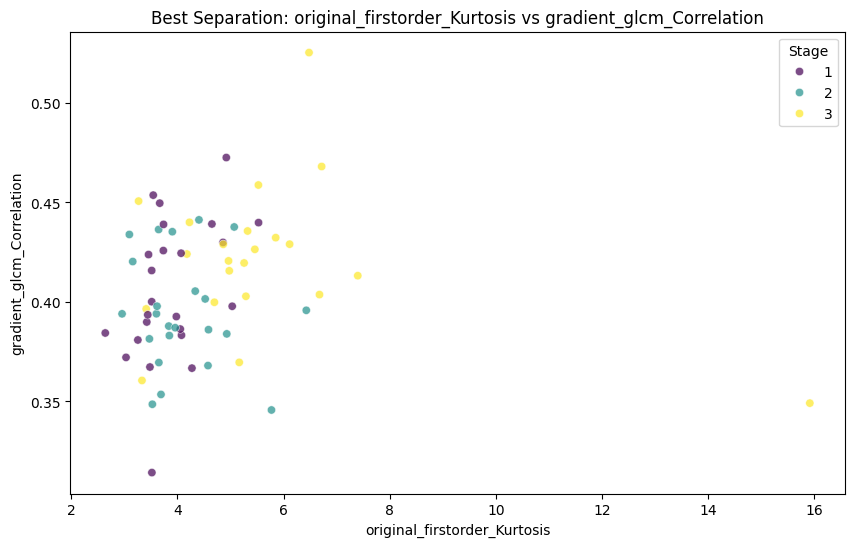

In [40]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

image_features = ["original_firstorder_Kurtosis", "original_glcm_MaximumProbability", "original_glcm_DifferenceAverage", "original_glcm_Idm",
                  "original_glcm_Id", "original_firstorder_Skewness", "gradient_glcm_Imc2", "gradient_glcm_Correlation"]

pd.set_option('future.no_silent_downcasting', True)
df_features = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

df_combined = pd.merge(clinical_df[['Patient ID', 'Stage']], df_features, left_on='Patient ID', right_on='patient', how='left')
df_final = df_combined.dropna(subset=['Stage']).drop(columns=['patient'])

X = df_final.select_dtypes(include=['number']).drop(columns=['Stage'], errors='ignore')
y = df_final['Stage']

f_values, _ = f_classif(X.fillna(0), y)
feature_f_map = dict(zip(image_features, f_values))

best_score = -1
best_pair = None

for feat1, feat2 in combinations(image_features, 2):
    current_score = feature_f_map[feat1] + feature_f_map[feat2]
    if current_score > best_score:
        best_score = current_score
        best_pair = (feat1, feat2)

print(f"Best Discriminative Pair: {best_pair}")
print(f"Combined F-score: {best_score:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x=best_pair[0], y=best_pair[1], hue='Stage', palette='viridis', alpha=0.7)
plt.title(f"Best Separation: {best_pair[0]} vs {best_pair[1]}")
plt.show()

# 2D clusters based on selected clinical features

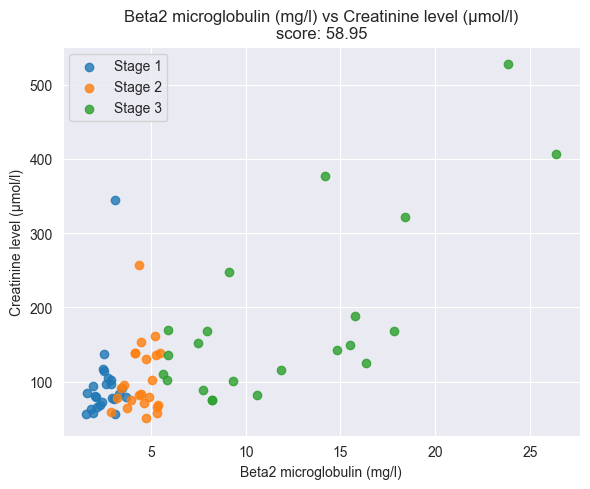

In [17]:
feature1 = 'Beta2 microglobulin (mg/l)'
feature2 = 'Creatinine level (µmol/l)'
features = [feature1, feature2]

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

clinical_df = clinical_df[clinical_df['Stage'].notna()]
clinical_df.drop(columns=['Patient ID'], inplace=True)

X = clinical_df[features].fillna(0)
y = clinical_df['Stage']
f_values, _ = f_classif(X, y)
feature_f_map = dict(zip(features, f_values))
current_score = feature_f_map[feature1] + feature_f_map[feature2]

plt.figure(figsize=(6,5))
for s in sorted(clinical_df['Stage'].unique()):
    idx = clinical_df['Stage'] == s
    plt.scatter(clinical_df.loc[idx, feature1], clinical_df.loc[idx, feature2], label=f"Stage {s}", alpha=0.8)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f"{feature1} vs {feature2}\n"
          f"score: {current_score:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

# Try to find the best clusters as possible

Hopkins statistic

- Hodnota ~0.5 → náhodné dáta (žiadne zhluky)
- Hodnota <<0.5 → zhluky prítomné

In [5]:
# HOPKINS STATISTIC
from pyclustertend import hopkins
import pandas as pd

for df_name, df in merged_lesions_csv(r"E:\DATA_Myelomy").items():
    X = StandardScaler().fit_transform(df.drop(columns=['patient']))
    h = hopkins(X, X.shape[0])
    print(f"Hopkins statistic for {df_name}: {h}")

Hopkins statistic for BMD: 0.21018908506742695
Hopkins statistic for CaSupp_25: 0.24433944004547092
Hopkins statistic for konv: 0.23588363526652803
Hopkins statistic for monoe_120kev: 0.22829804864712164
Hopkins statistic for monoe_40kev: 0.25579779260380303
Hopkins statistic for monoe_80kev: 0.24185505820576564


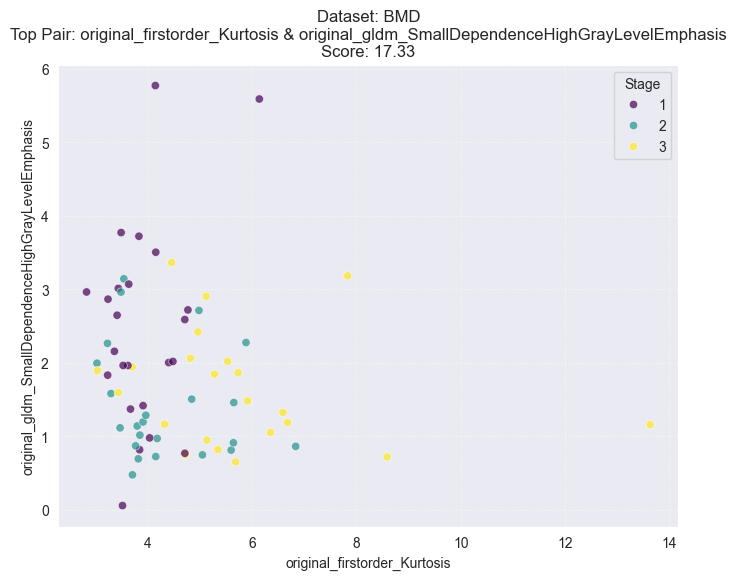

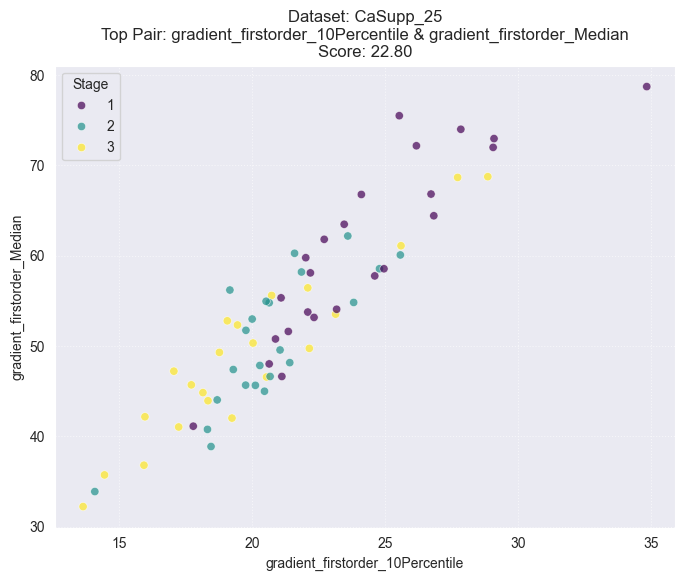

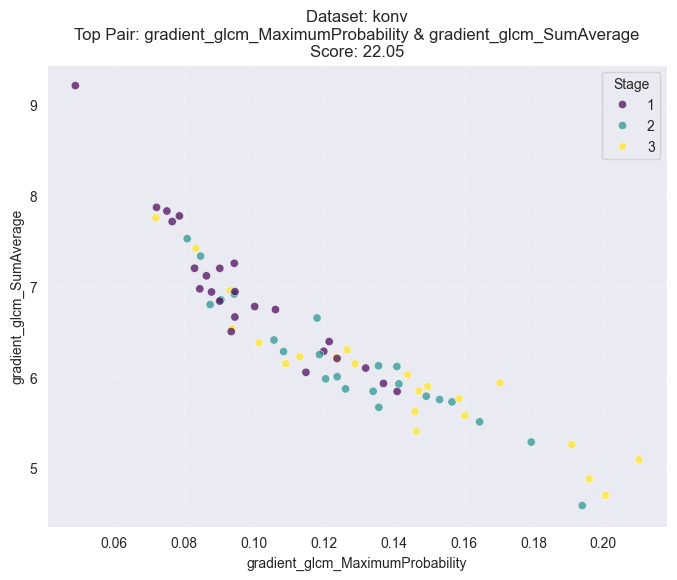

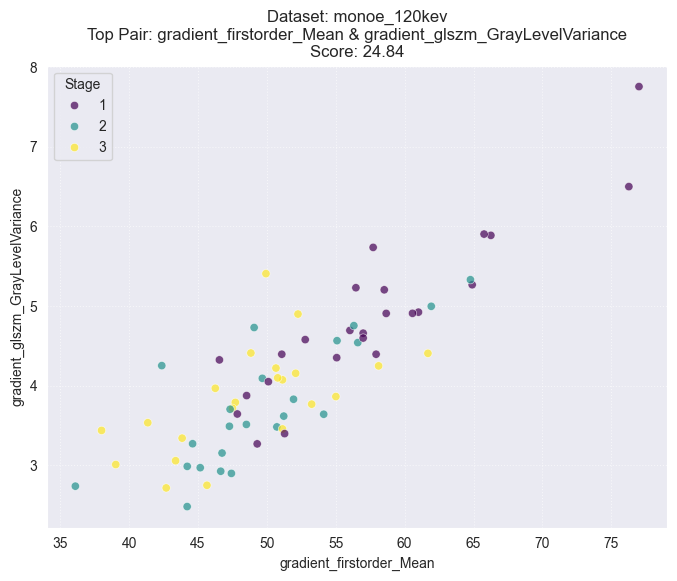

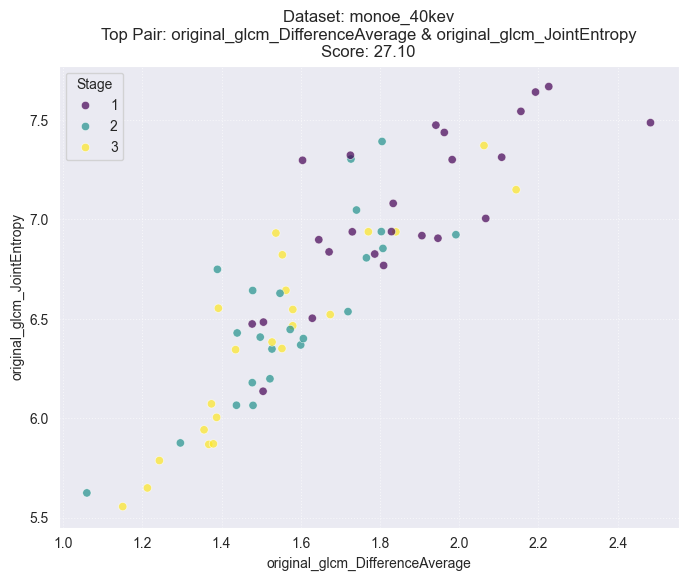

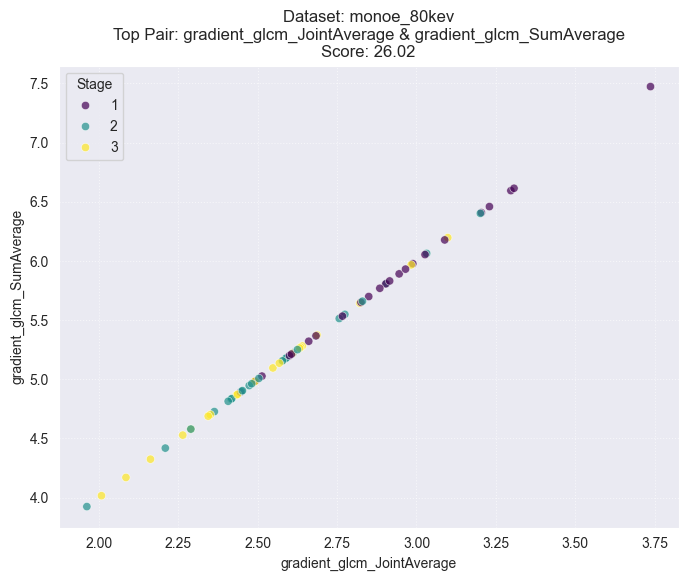

In [24]:
import seaborn as sns

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df_features in merged_lesions_csv(r"E:\DATA_Myelomy").items():
    df_combined = pd.merge(clinical_df[['Patient ID', 'Stage']], df_features, left_on='Patient ID', right_on='patient', how='left')
    df_final = df_combined.dropna(subset=['Stage'])

    y = df_final['Stage']
    X = df_final.select_dtypes(include=['number']).drop(columns=['Stage'], errors='ignore')

    X = X.fillna(0)
    features = X.columns.tolist()
    f_values, _ = f_classif(X, y)
    feature_f_map = dict(zip(features, f_values))

    best_score = -1
    best_pair = None

    for feat1, feat2 in combinations(features, 2):
        score = feature_f_map[feat1] + feature_f_map[feat2]
        if score > best_score:
            best_score = score
            best_pair = (feat1, feat2)

    if best_pair:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X[best_pair[0]], y=X[best_pair[1]], hue=y, palette='viridis', alpha=0.7)
        plt.title(f"Dataset: {df_name}\nTop Pair: {best_pair[0]} & {best_pair[1]}\nScore: {best_score:.2f}")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

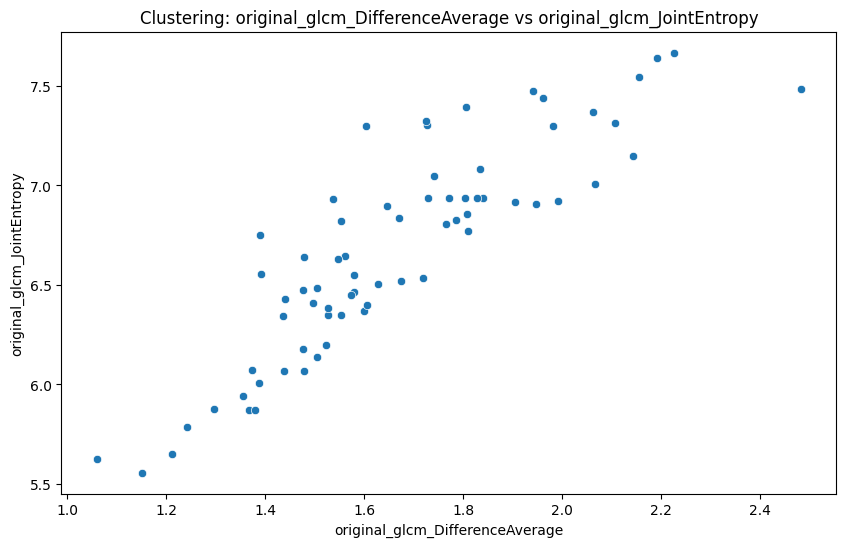

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x=best_pair[0], y=best_pair[1])
plt.title(f"Clustering: {best_pair[0]} vs {best_pair[1]}")
plt.show()

# Merge all maps features to one -> best 2D cluster

In [10]:
import pandas as pd
from functools import reduce

id_col = 'patient'
combined_df_list = []

for dataset_name, df in merged_lesions_csv(r"E:\DATA_Myelomy").items():
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    cols_to_keep = [id_col] + [c for c in numeric_cols if c != id_col]
    temp_df = df[cols_to_keep].copy()
    temp_df = temp_df.rename(columns={c: f"{dataset_name}_{c}" for c in numeric_cols if c != id_col})

    combined_df_list.append(temp_df)

combined_df = reduce(lambda left, right: pd.merge(left, right, on=id_col, how='outer'), combined_df_list)
combined_df

,patient,BMD_n_lesions,BMD_original_shape_Elongation,BMD_original_shape_Flatness,BMD_original_shape_LeastAxisLength,BMD_original_shape_MajorAxisLength,BMD_original_shape_Maximum2DDiameterColumn,BMD_original_shape_Maximum2DDiameterRow,BMD_original_shape_Maximum2DDiameterSlice,BMD_original_shape_Maximum3DDiameter,...,monoe_80kev_gradient_gldm_LargeDependenceLowGrayLevelEmphasis,monoe_80kev_gradient_gldm_LowGrayLevelEmphasis,monoe_80kev_gradient_gldm_SmallDependenceEmphasis,monoe_80kev_gradient_gldm_SmallDependenceHighGrayLevelEmphasis,monoe_80kev_gradient_gldm_SmallDependenceLowGrayLevelEmphasis,monoe_80kev_gradient_ngtdm_Busyness,monoe_80kev_gradient_ngtdm_Coarseness,monoe_80kev_gradient_ngtdm_Complexity,monoe_80kev_gradient_ngtdm_Contrast,monoe_80kev_gradient_ngtdm_Strength
0,Myel_001,42,0.208989,0.090847,48.159211,530.112286,489.628282,477.609470,70.013470,524.164765,...,10.958494,0.215969,0.150260,4.975312,0.023879,8.901407,0.001025,373.109539,0.014480,0.889986
1,Myel_002,26,0.312599,0.177995,56.369710,316.692125,312.249080,221.602910,62.017486,350.835395,...,30.042147,0.315859,0.088350,1.977885,0.015691,52.858414,0.000434,79.481747,0.018910,0.073252
2,Myel_003,8,0.212993,0.151570,36.779577,242.656717,119.996801,223.869005,26.654969,272.417997,...,15.295225,0.264689,0.113543,3.107458,0.021510,4.824119,0.003358,145.971692,0.017245,1.252462
3,Myel_004,54,0.159400,0.086384,43.732812,506.259109,448.915430,452.701719,83.059497,506.152358,...,35.156534,0.331646,0.113942,3.598346,0.016212,99.647918,0.000131,250.301284,0.014264,0.083218
4,Myel_005,12,0.192710,0.149551,57.235029,382.711335,214.831665,320.170141,47.350217,373.626743,...,11.211558,0.190617,0.125523,3.925351,0.018671,17.238918,0.001040,107.283384,0.032399,0.159752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Myel_077,89,0.233804,0.087668,45.004290,513.347438,402.978760,519.557773,91.077216,524.753774,...,24.886522,0.298153,0.098329,2.363982,0.018454,96.807489,0.000147,184.983242,0.011575,0.071391
68,Myel_078,74,0.204975,0.091256,38.972118,427.062695,369.135680,448.864329,69.583076,448.868578,...,15.724846,0.218892,0.156243,6.458687,0.018733,126.018146,0.000063,536.523306,0.019765,0.058542
69,Myel_079,27,0.101824,0.043274,26.700219,617.003616,382.426535,506.295135,41.068099,509.125937,...,18.675069,0.246674,0.101382,2.200123,0.020623,25.404090,0.000725,108.111115,0.016244,0.169699
70,Myel_080,50,0.181550,0.102740,42.502876,413.693927,370.293745,485.256220,74.276550,485.787949,...,21.295897,0.262232,0.090217,2.347879,0.017718,247.061179,0.000055,190.261930,0.011556,0.026382


Best Discriminative Pair: ('monoe_40kev_original_glcm_DifferenceAverage', 'monoe_40kev_original_glcm_JointEntropy')
Combined F-score: 27.10


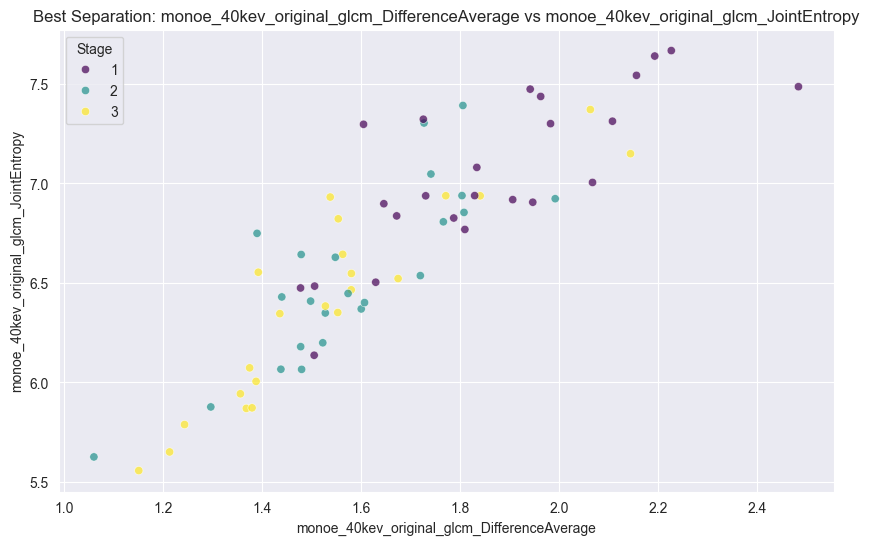

In [16]:
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

df = pd.merge(clinical_df[['Patient ID', 'Stage']], combined_df, left_on='Patient ID', right_on='patient', how='left')
df_final = df.dropna(subset=['Stage']).drop(columns=['patient'])

X = df_final.select_dtypes(include=['number']).drop(columns=['Stage'], errors='ignore')
y = df_final['Stage']
features = X.columns.tolist()

f_values, _ = f_classif(X.fillna(0), y)
feature_f_map = dict(zip(features, f_values))

best_score = -1
best_pair = None

for feat1, feat2 in combinations(features, 2):
    current_score = feature_f_map[feat1] + feature_f_map[feat2]
    if current_score > best_score:
        best_score = current_score
        best_pair = (feat1, feat2)

print(f"Best Discriminative Pair: {best_pair}")
print(f"Combined F-score: {best_score:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x=best_pair[0], y=best_pair[1], hue='Stage', palette='viridis', alpha=0.7)
plt.title(f"Best Separation: {best_pair[0]} vs {best_pair[1]}")
plt.show()

# t-SNE

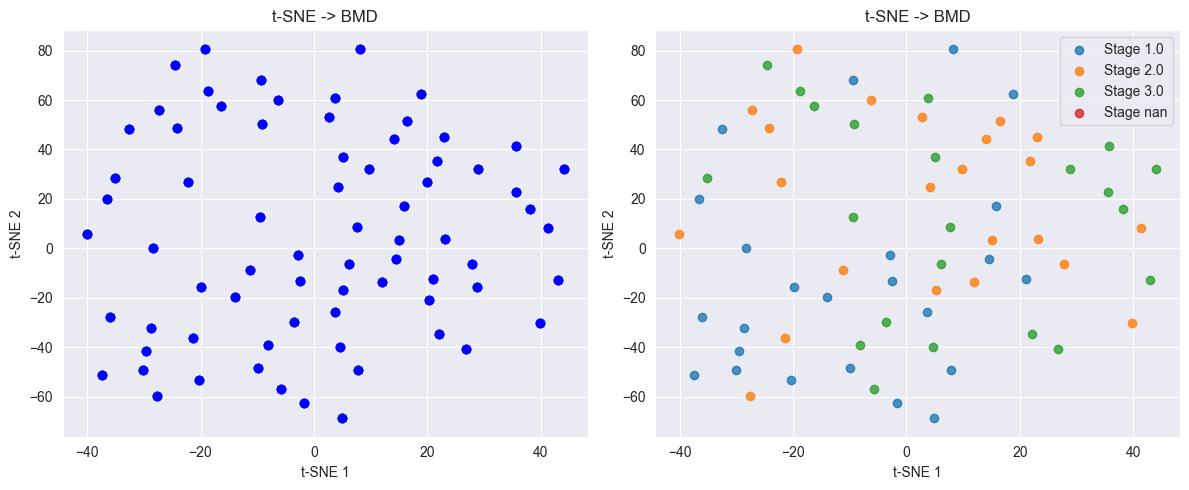

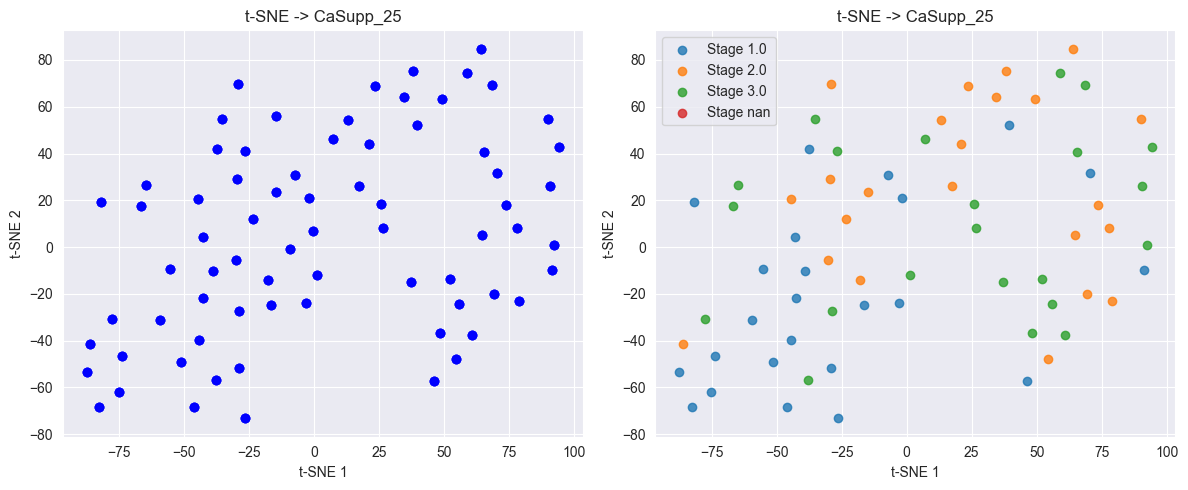

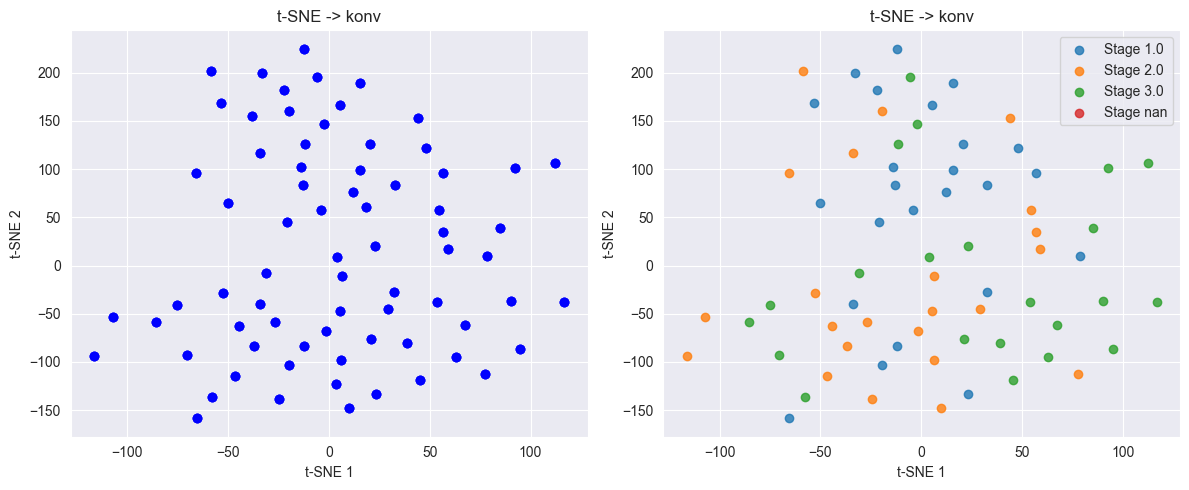

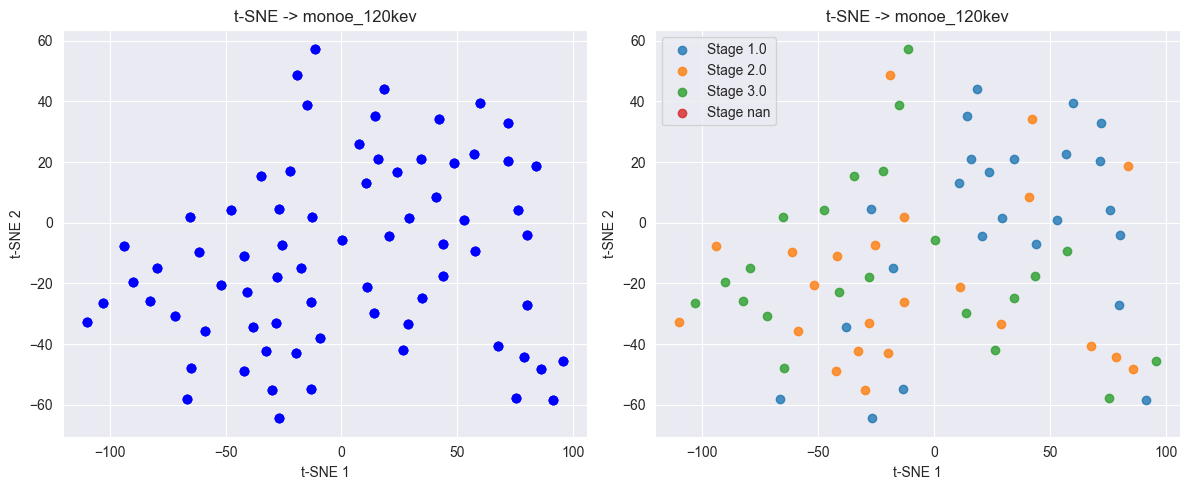

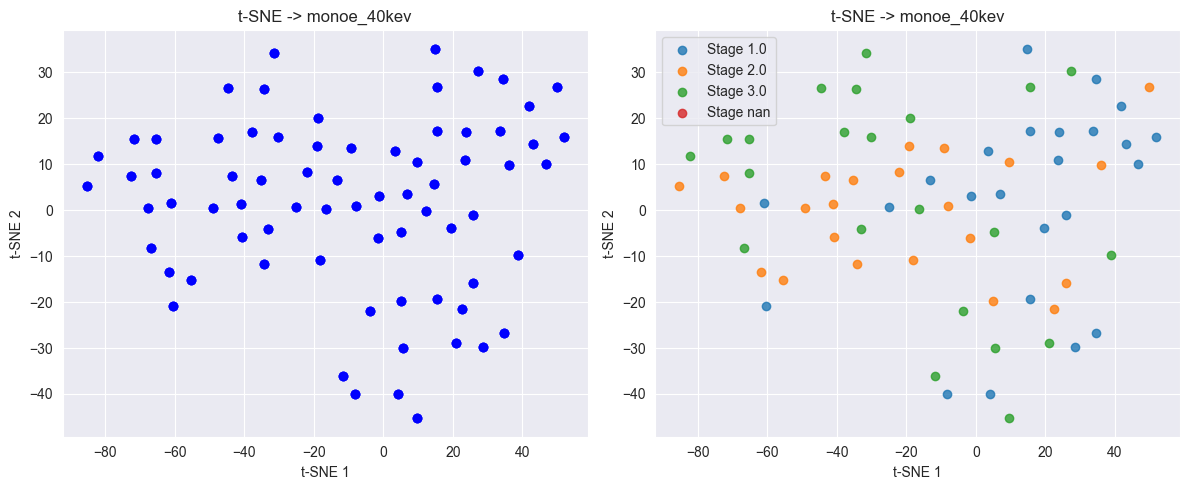

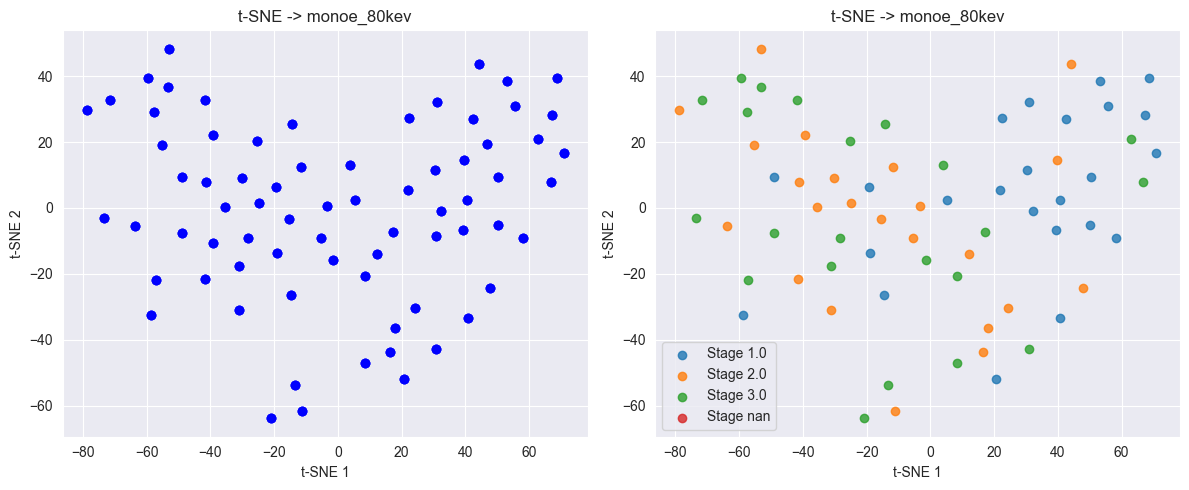

In [2]:
from helper_files.feature_selection_helper import *
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

merged = merged_lesions_csv(r"E:\DATA_Myelomy")
clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    tsne = TSNE(perplexity=15, learning_rate=200, random_state=42)
    data_tsne = tsne.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s

        plt.subplot(122)
        plt.scatter(data_tsne[idx, 0], data_tsne[idx, 1], label=f"Stage {s}", alpha=0.8)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title(f"t-SNE -> {df_name}")
        plt.legend()

        plt.subplot(121)
        plt.scatter(data_tsne[:, 0], data_tsne[:, 1], color='blue', alpha=0.7)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title(f"t-SNE -> {df_name}")

    plt.tight_layout()
    plt.show()

# t-SNE on selected features

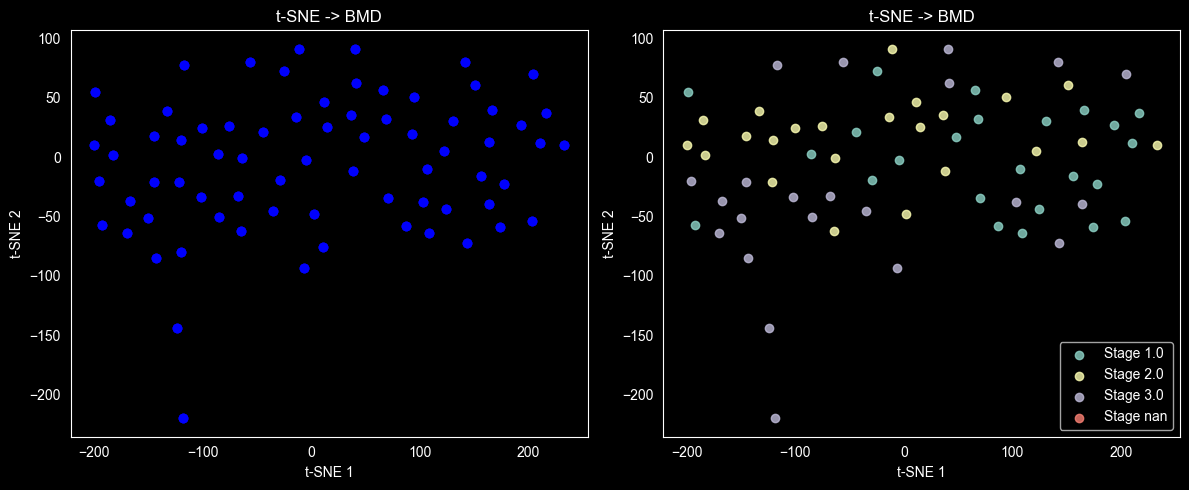

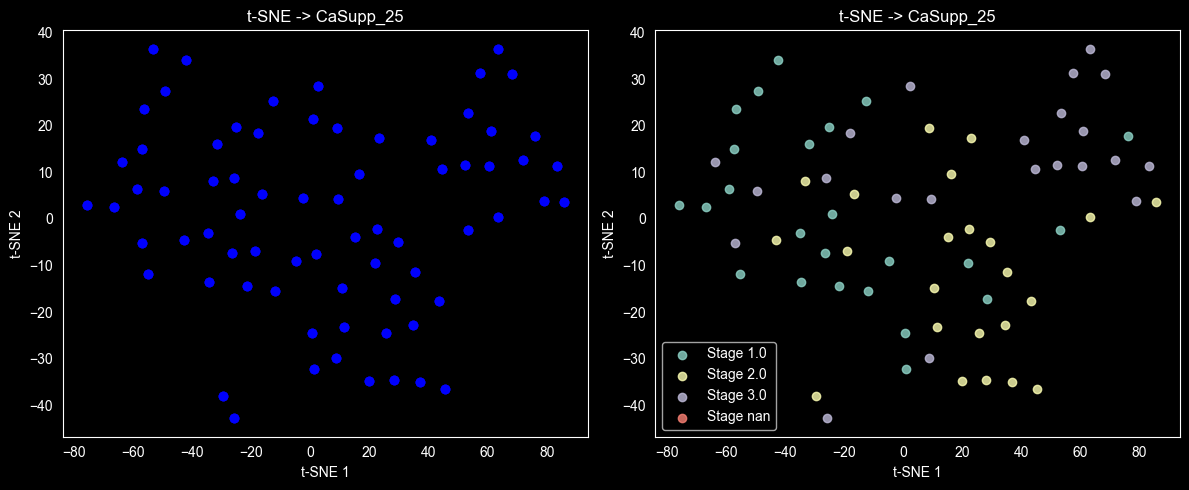

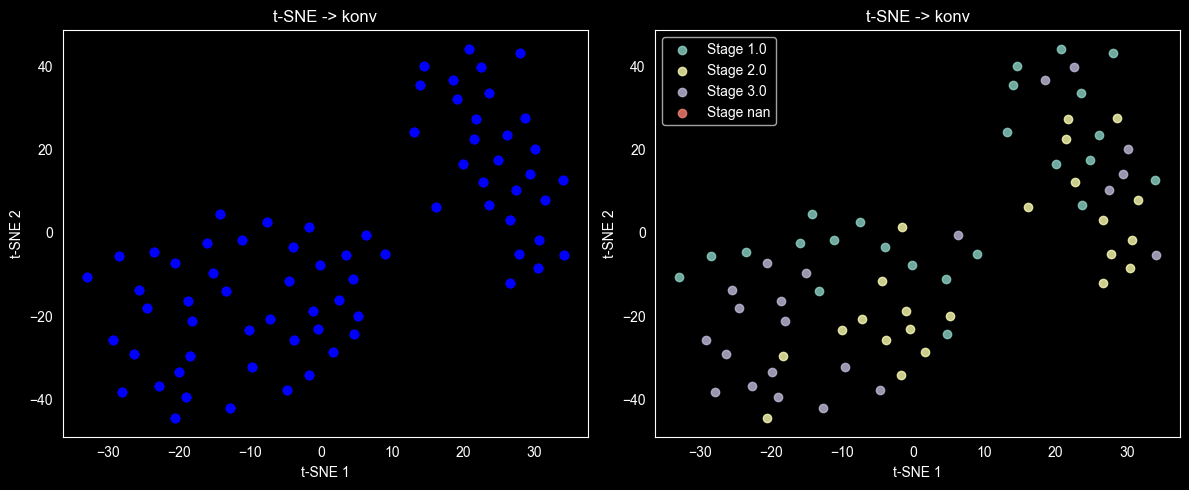

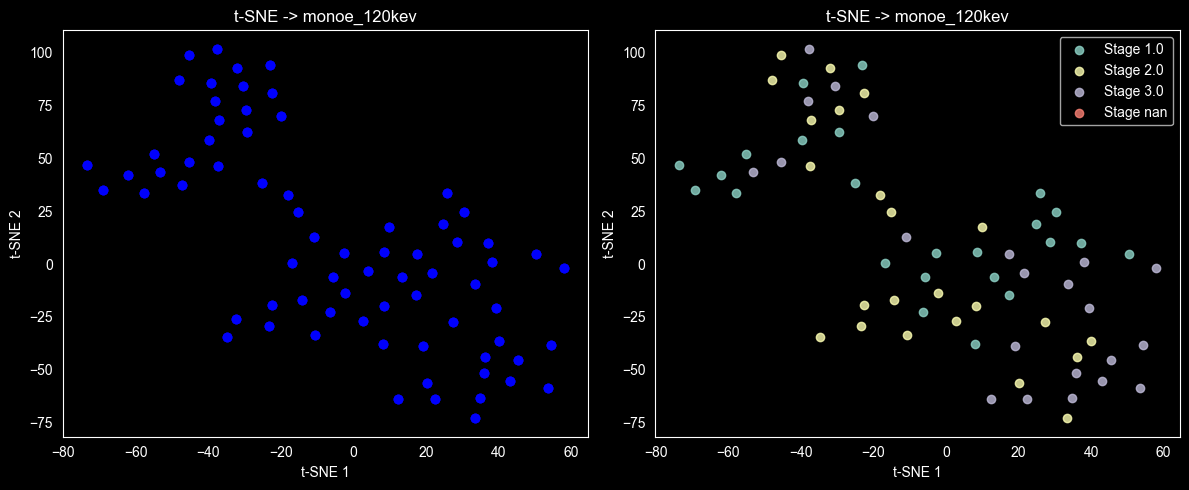

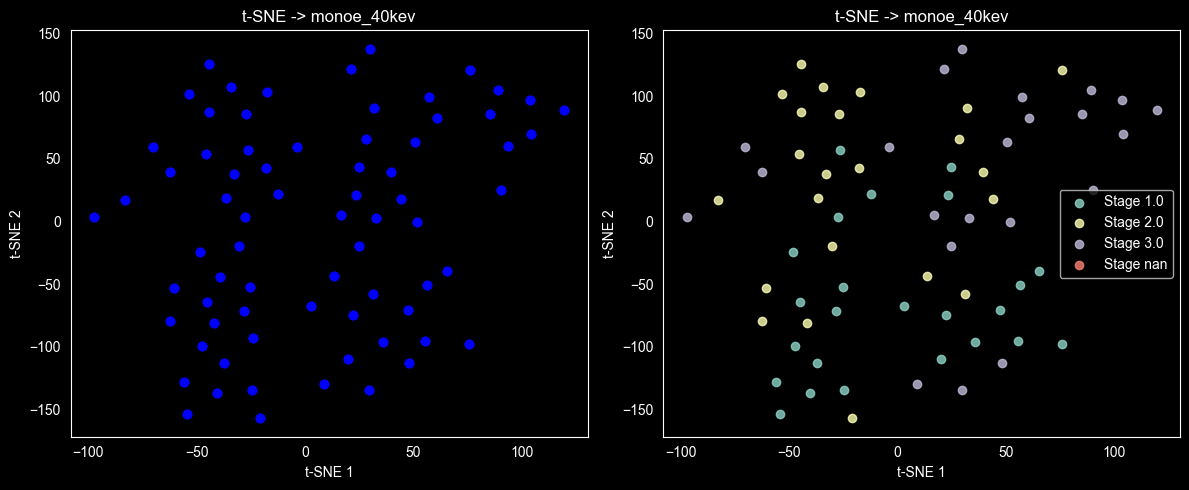

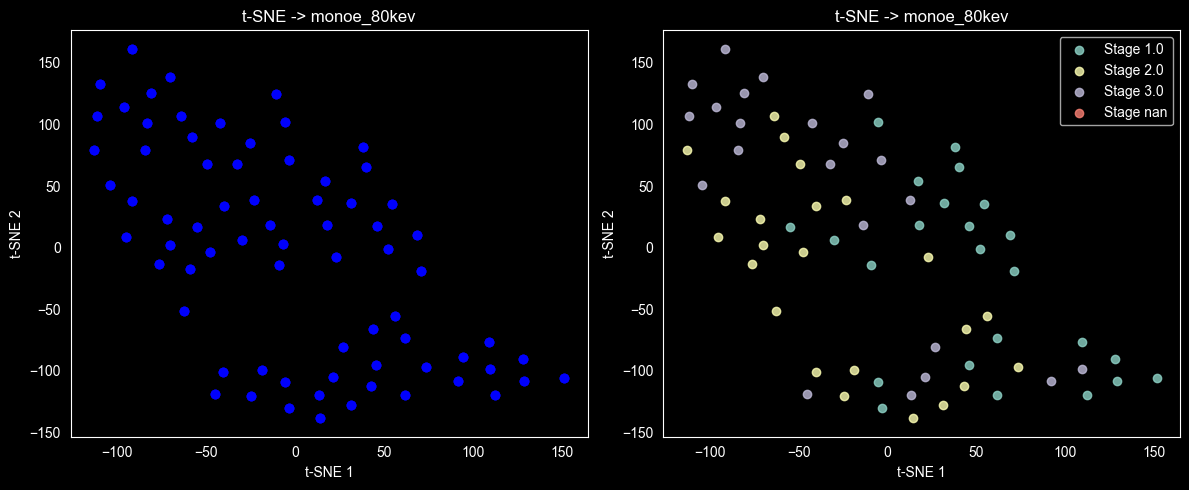

In [3]:
from helper_files.feature_selection_helper import *
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

img_features = ["original_firstorder_Kurtosis", "original_glcm_MaximumProbability", "original_glcm_DifferenceAverage", "original_glcm_Idm",
                  "original_glcm_Id", "original_firstorder_Skewness", "gradient_glcm_Imc2", "gradient_glcm_Correlation"]
merged = merged_lesions_csv(r"E:\DATA_Myelomy")
clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features[img_features])

    tsne = TSNE(perplexity=15, learning_rate=200, random_state=42)
    data_tsne = tsne.fit_transform(df_scaled)

    plt.figure(figsize=(12, 5))
    for s in sorted(stage.unique()):
        idx = stage == s

        plt.subplot(122)
        plt.scatter(data_tsne[idx, 0], data_tsne[idx, 1], label=f"Stage {s}", alpha=0.8)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title(f"t-SNE -> {df_name}")
        plt.grid(False)
        plt.legend()

        plt.subplot(121)
        plt.scatter(data_tsne[:, 0], data_tsne[:, 1], color='blue', alpha=0.7)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title(f"t-SNE -> {df_name}")
        plt.grid(False)

    plt.tight_layout()
    plt.show()